In [58]:
from dotenv import load_dotenv
load_dotenv()

True

In [59]:
import os
os.environ["PINECONE_API_KEY"] = os.getenv("PINECONE_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [60]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [61]:
model.invoke("hi").content[0]["text"]

'Hello! How can I help you today?'

In [62]:
def function1(input1):
    return  input1 + " response from first function"

In [63]:
def function2(input2):
    return input2+ " response from second function"

In [64]:
from langgraph.graph import StateGraph, START, END

In [65]:
def my_node_function(state: dict) -> dict:
    return {"messages": state["a"] + state["b"]}

In [66]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

class State(TypedDict):
    a: int
    b: int
    messages: int

builder = StateGraph(State)
builder.add_node("my_node", my_node_function)
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)

graph = builder.compile()

In [67]:
graph.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'my_node': Node(id='my_node', name='my_node', data=my_node(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='my_node', data=None, conditional=False), Edge(source='my_node', target='__end__', data=None, conditional=False)])

In [68]:
from IPython.display import Image, display

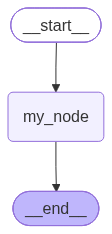

In [69]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [70]:
graph.invoke({"a":1, "b":2})

{'a': 1, 'b': 2, 'messages': 3}